In [ ]:
###
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [4]:
tips=sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


[Text(0.5, 1.0, 'Tips vs Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

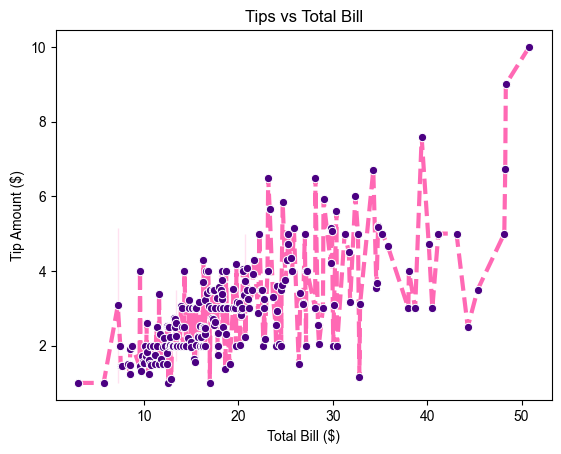

In [5]:
tipgraph=sns.lineplot(data=tips, x='total_bill', y='tip', 
                      color='hotpink', 
                      linestyle='--', 
                      linewidth=3,
                      marker='o',
                      markerfacecolor='indigo')
###light blue -infrequent tip amount, dark blue-frequent tip amount

sns.set_style('whitegrid')
#sns.set_style('darkgrid')

tipgraph.set(title='Tips vs Total Bill', 
             xlabel="Total Bill ($)", 
             ylabel="Tip Amount ($)")

[Text(0.5, 1.0, 'Tips vs Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

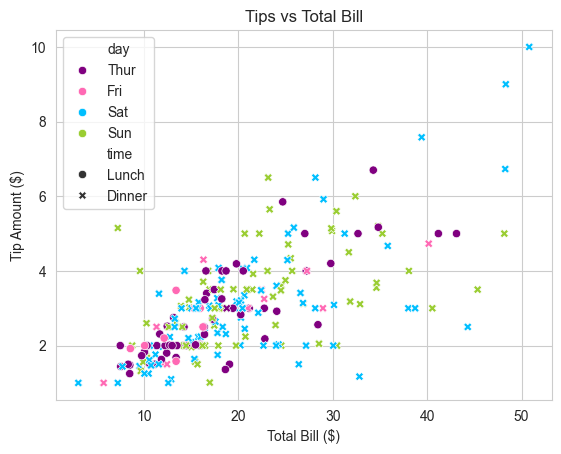

In [6]:
tipgraph=sns.scatterplot(data=tips, x='total_bill', 
                          y='tip',style='time', hue='day', 
                          palette=['purple', 'hotpink', 'deepskyblue', 
                                   'yellowgreen'])
tipgraph.set(title='Tips vs Total Bill', 
             xlabel="Total Bill ($)", 
             ylabel="Tip Amount ($)")

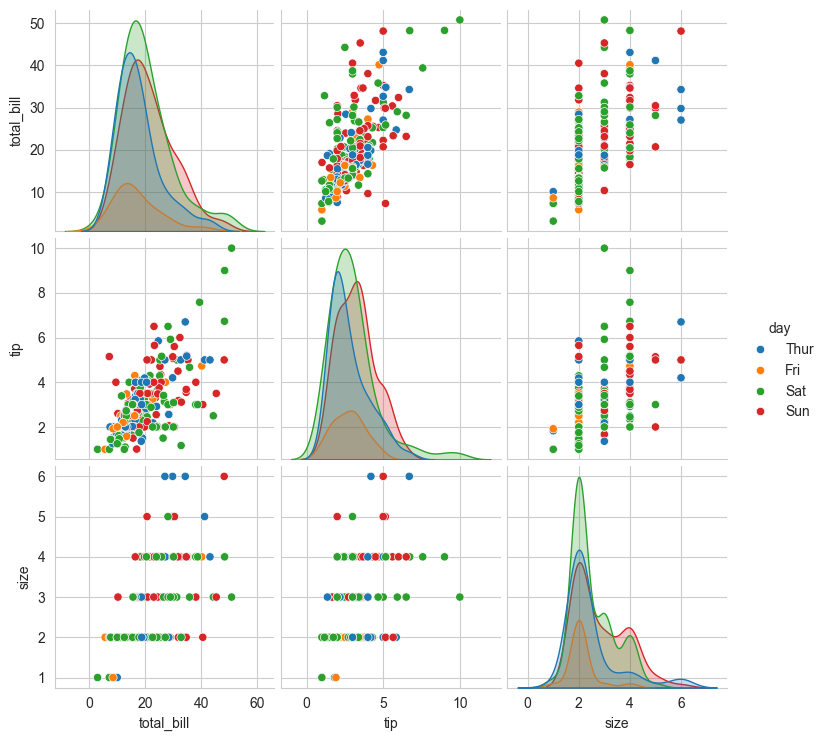

In [7]:
sns.pairplot(data=tips, hue='day')## present all relationships amongst variables. 

In [9]:
import plotly.graph_objects as go
from wordcloud import WordCloud
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

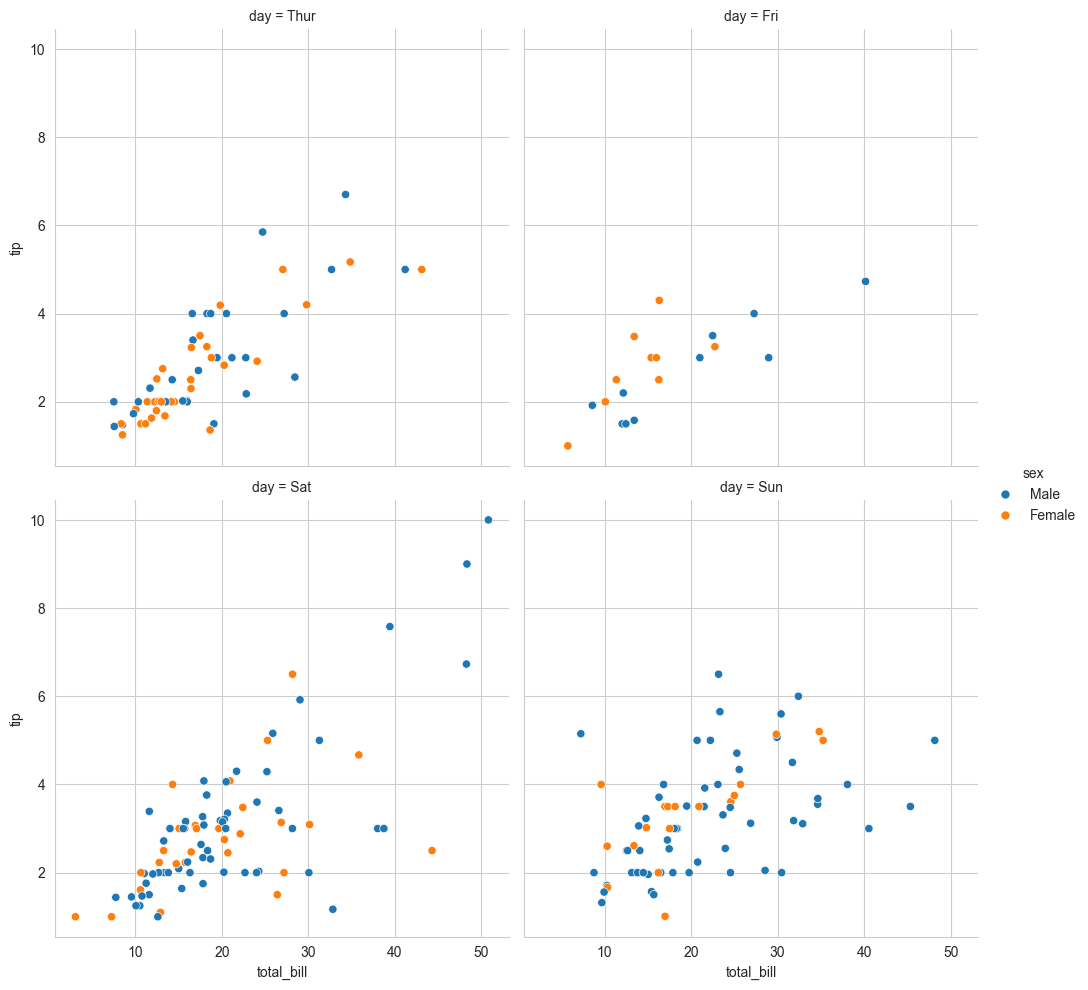

In [14]:
daysplot=sns.relplot(data=tips, x='total_bill', 
                    y='tip', 
                    hue="sex", 
                    col='day', 
                    kind='scatter', 
                    col_wrap=2)

In [16]:
import plotly.graph_objects as go #go is graph objects
x1=np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1=np.array([110, 180, 240, 99, 220])


In [ ]:
graph=go.Figure() ## the figure is named graph

graph.add_trace(go.Bar(x=x1, y=y1)) ### add bar chart to the figure 

In [18]:
graph.update_layout(
    title="Pirate Scores", 
    xaxis_title="Pirates", 
    yaxis_title="Score")


In [ ]:
graph.show()
#graph.write_html("mygraph.html")

In [30]:
graph=go.Figure()
graph.add_trace(go.Scatter(x=x1, y=y1, mode='markers', 
                marker=dict(size=15, color='hotpink', opacity=1, ### point size and colour
                            line=dict(width=5, color='purple')))) ### point outline


graph.update_layout(
    title="Interactive Pirate Plot", 
    xaxis_title="Pirates", 
    yaxis_title="Score")

In [31]:
from wordcloud import WordCloud
df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
on_bad_lines='skip')
print(df)

                                                 quote  \
0                      Do, or do not. There is no try.   
1    Listen to them. Children of the night. What mu...   
2                              It's alive! It's alive!   
3    Oh, no, it wasn't the airplanes. It was Beauty...   
4    Magic Mirror on the wall, who is the fairest o...   
..                                                 ...   
727  I didn't know if you were lost. Stick with me....   
728  This guy's awesome! He's holding his own while...   
729     Murder is murder, it don’t matter who you are.   
730  You know what a lion is? A lion is a strong an...   
731  That was the best acting i've ever seen in my ...   

                                              movie   type  year  
0    Star Wars: Episode V - The Empire Strikes Back  movie  1890  
1                                           Dracula  movie  1931  
2                                      Frankenstein  movie  1931  
3                                  

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

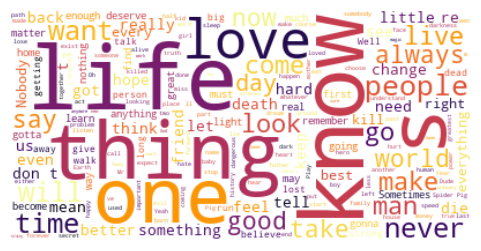

In [ ]:
# Join different quotes
text= " ".join(each for each in df.quote) ### glue all texts together (each for each, glue each text together, but different quotes, we use space to separate them)

#generate our wordcloud image

wordcloud=WordCloud(background_color="white", 
                    colormap='inferno').generate(text)

#use matplotlib syntax to put our image in a figure
fig, ax=plt.subplots(figsize=(7,3))

ax.imshow(wordcloud, interpolation='bilinear') ### imshow adds image to plot, bilinear-to smooth our image. 
ax.axis("off")
### generates colors for words randomly each time, and positioned in differet ways. 

In [36]:
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

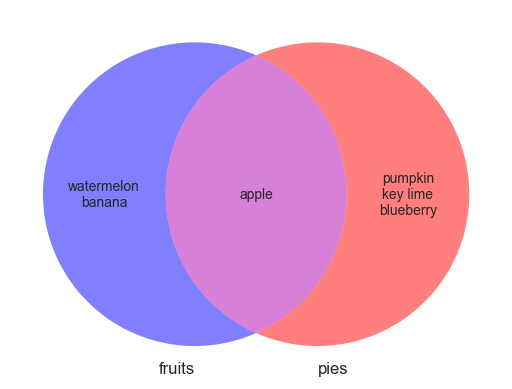

In [ ]:
diagram=venn2_unweighted([A, B], 
                         set_labels= ("fruits", "pies"), 
                         set_colors= ("blue", "red"),
                            alpha=0.5)



diagram.get_label_by_id("10").set_text("\n".join(A-B)) ### 10 inside A, but not inside B, 11-inside A and B,

diagram.get_label_by_id("11").set_text("\n".join(A&B))
diagram.get_label_by_id("01").set_text("\n".join(B-A))